# Coding Task: Bias‑Variance for a Sine Target

**Goal:** Compare constant and linear models on a non‑linear target function. Compute bias, variance, and expected error for different training set sizes.

## Background

- True target: \( f(x) = \sin(2\pi x) \) on \( x \in [0,1] \).
- Training data: \( y = f(x) + \epsilon \), where \( \epsilon \sim \mathcal{N}(0, 0.3^2) \).
- Two hypothesis models:
  1. **Constant model**: \( h_0(x) = c \) (fits the mean of training \( y \)’s).
  2. **Linear model**: \( h_1(x) = w_0 + w_1 x \) (fits least‑squares line).
- Fix a **test point** \( x_{\text{test}} = 0.6 \). Its true value is \( f(0.6) = \sin(1.2\pi) \approx -0.5878 \).

For a given training set size \( N \):
- Generate many datasets (e.g., 200).
- For each dataset, train both models and record their predictions at \( x_{\text{test}} \).
- Compute:
  - **Bias²** = \( (\bar{h} - f_{\text{true}})^2 \) where \( \bar{h} \) is average prediction.
  - **Variance** = \( \frac{1}{K}\sum (h - \bar{h})^2 \).
  - **Total error** = Bias² + Variance.
- Repeat for \( N = 2, 3, 5 \) and compare models.

## What You Will Do

1. Implement functions to generate data, fit constant model, fit linear model.
2. Run simulation for \( N = 2, 3, 5 \), each with 200 repetitions.
3. Compute bias², variance, total error for each model and each \( N \).
4. Plot results (bar charts or line plots).
5. Answer the questions.

## Deliverable

Submit this notebook with all cells executed and your answers.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def generate_data(N, noise_std=0.3, x_range=(0,1)):
    """
    Generate N random points from x in [0,1].
    y = sin(2πx) + Gaussian noise.
    Returns: x (N,), y (N,)
    """
    x = np.random.uniform(x_range[0], x_range[1], N)
    x_sorted = np.sort(x)   # only for nicer plots, not required
    y = np.sin(2 * np.pi * x_sorted) + np.random.normal(0, noise_std, N)
    return x_sorted, y

# True function for plotting
x_true = np.linspace(0, 1, 500)
y_true = np.sin(2 * np.pi * x_true)

In [11]:
def constant_model(x_train, y_train):
    """Fit constant model: h(x) = c, where c = mean(y_train)."""
    c = np.mean(y_train)
    return c

def linear_model(x_train, y_train):
    """Fit linear model: h(x) = w0 + w1*x."""
    w1, w0 = np.polyfit(x_train, y_train, 1)
    def predict(x):
        return w0 + w1 * x
    return predict

In [15]:
def bias_variance_simulation(N, num_repeats=200, test_x=0.6):
    """
    For a fixed test point test_x, compute bias^2, variance, total error
    for both constant and linear models.
    Returns: dict with keys 'constant' and 'linear', each containing
             lists: [bias_sq, variance, total]
    """
    true_value = np.sin(2 * np.pi * test_x)
    const_preds = []
    lin_preds = []
    
    for _ in range(num_repeats):
        x_train, y_train = generate_data(N)
        # Constant model prediction
        c = constant_model(x_train, y_train)
        const_preds.append(c)
        # Linear model prediction
        lin_predict = linear_model(x_train, y_train)
        lin_preds.append(lin_predict(test_x))
    
    const_preds = np.array(const_preds)
    lin_preds = np.array(lin_preds)
    
    def compute_metrics(preds):
        mean_pred = np.mean(preds)
        bias_sq = (mean_pred - true_value)**2
        variance = np.mean((preds - mean_pred)**2)
        total = bias_sq + variance
        return bias_sq, variance, total
    
    const_metrics = compute_metrics(const_preds)
    lin_metrics = compute_metrics(lin_preds)
    
    return {'constant': const_metrics, 'linear': lin_metrics}

In [17]:
N_values = [2, 3, 5]
num_repeats = 200
test_x = 0.6

results = {N: bias_variance_simulation(N, num_repeats, test_x) for N in N_values}

print(f"{'N':<3} {'Model':<8} {'Bias²':<12} {'Variance':<12} {'Total Error':<12}")
print("-" * 50)
for N in N_values:
    for model in ['constant', 'linear']:
        b, v, t = results[N][model]
        print(f"{N:<3} {model:<8} {b:<12.4f} {v:<12.4f} {t:<12.4f}")
    print("-" * 50)

N   Model    Bias²        Variance     Total Error 
--------------------------------------------------
2   constant 0.3464       0.3110       0.6574      
2   linear   521.3946     99959.2050   100480.5996 
--------------------------------------------------
3   constant 0.2877       0.1785       0.4662      
3   linear   0.1789       0.5861       0.7651      
--------------------------------------------------
5   constant 0.3810       0.1267       0.5077      
5   linear   0.1489       0.1285       0.2774      
--------------------------------------------------


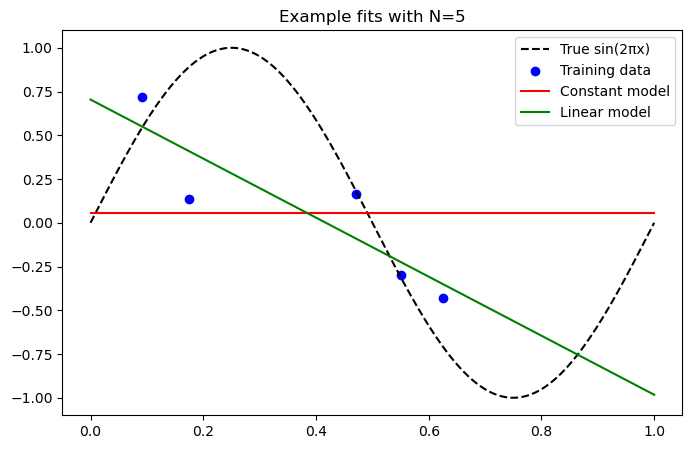

In [21]:
## Questions to Answer

x_train, y_train = generate_data(5)
x_plot = np.linspace(0,1,200)

c = constant_model(x_train, y_train)
y_const = np.full_like(x_plot, c)

lin = linear_model(x_train, y_train)
y_lin = lin(x_plot)

plt.figure(figsize=(8,5))
plt.plot(x_true, y_true, 'k--', label='True sin(2πx)')
plt.scatter(x_train, y_train, c='blue', label='Training data')
plt.plot(x_plot, y_const, 'r-', label='Constant model')
plt.plot(x_plot, y_lin, 'g-', label='Linear model')
plt.legend()
plt.title('Example fits with N=5')
plt.show()